### Access This Notebook

You can access a copy of this notebook using the link below:

https://colab.research.google.com/drive/19c1RepqeulmNyI9R2PwXcJJOEot8Qwxu?usp=sharing

Copy and paste this link into your browser to open it in Google Colab. You can then save your own copy and make your own edits.

### Connect to Google Drive

Connect this notebook to Google Drive so we can access our dataset.

Run the code below and follow the prompt to authorize access. Your Drive will then appear as a folder we can read from.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load the Dataset

In this step, we load the predictive maintenance dataset into a pandas DataFrame.

Before running the code:
1. Download the dataset from: https://tinyurl.com/grccdemo  
2. Upload the file to your Google Drive  
3. Locate the file in Drive, right-click, and copy its path  

Update the `file_path` below to match the location of your file.

We then preview the dataset to understand its size and structure.

In [2]:
import pandas as pd

# Path to the dataset in Google Drive
file_path = "/content/drive/MyDrive/CIS Teaching Demo 2026/[Dataset] predictive_maintenance.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Preview the data
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 10)


,UDI,Product_ID,Type,Air_temperature_[K],Process_temperature_[K],Rotational_speed_[rpm],Torque_[Nm],Tool_wear_[min],Target,Failure_Type
0,3237,M18096,M,300.8,309.4,1342,62.4,113,1,Heat Dissipation Failure
1,3761,L50940,L,302.3,310.9,1377,46.8,166,1,Heat Dissipation Failure
2,3788,L50967,L,302.3,310.8,1377,47.3,22,1,Heat Dissipation Failure
3,3794,L50973,L,302.3,310.9,1379,49.3,34,1,Heat Dissipation Failure
4,3807,M18666,M,302.3,310.9,1360,44.0,67,1,Heat Dissipation Failure


### Compare Features for Failure vs. No Failure

In this step, we visualize how key machine measurements differ between normal operation (Target = 0) and failure cases (Target = 1).

These comparisons help us identify patterns in the data that may be useful for predicting failures.

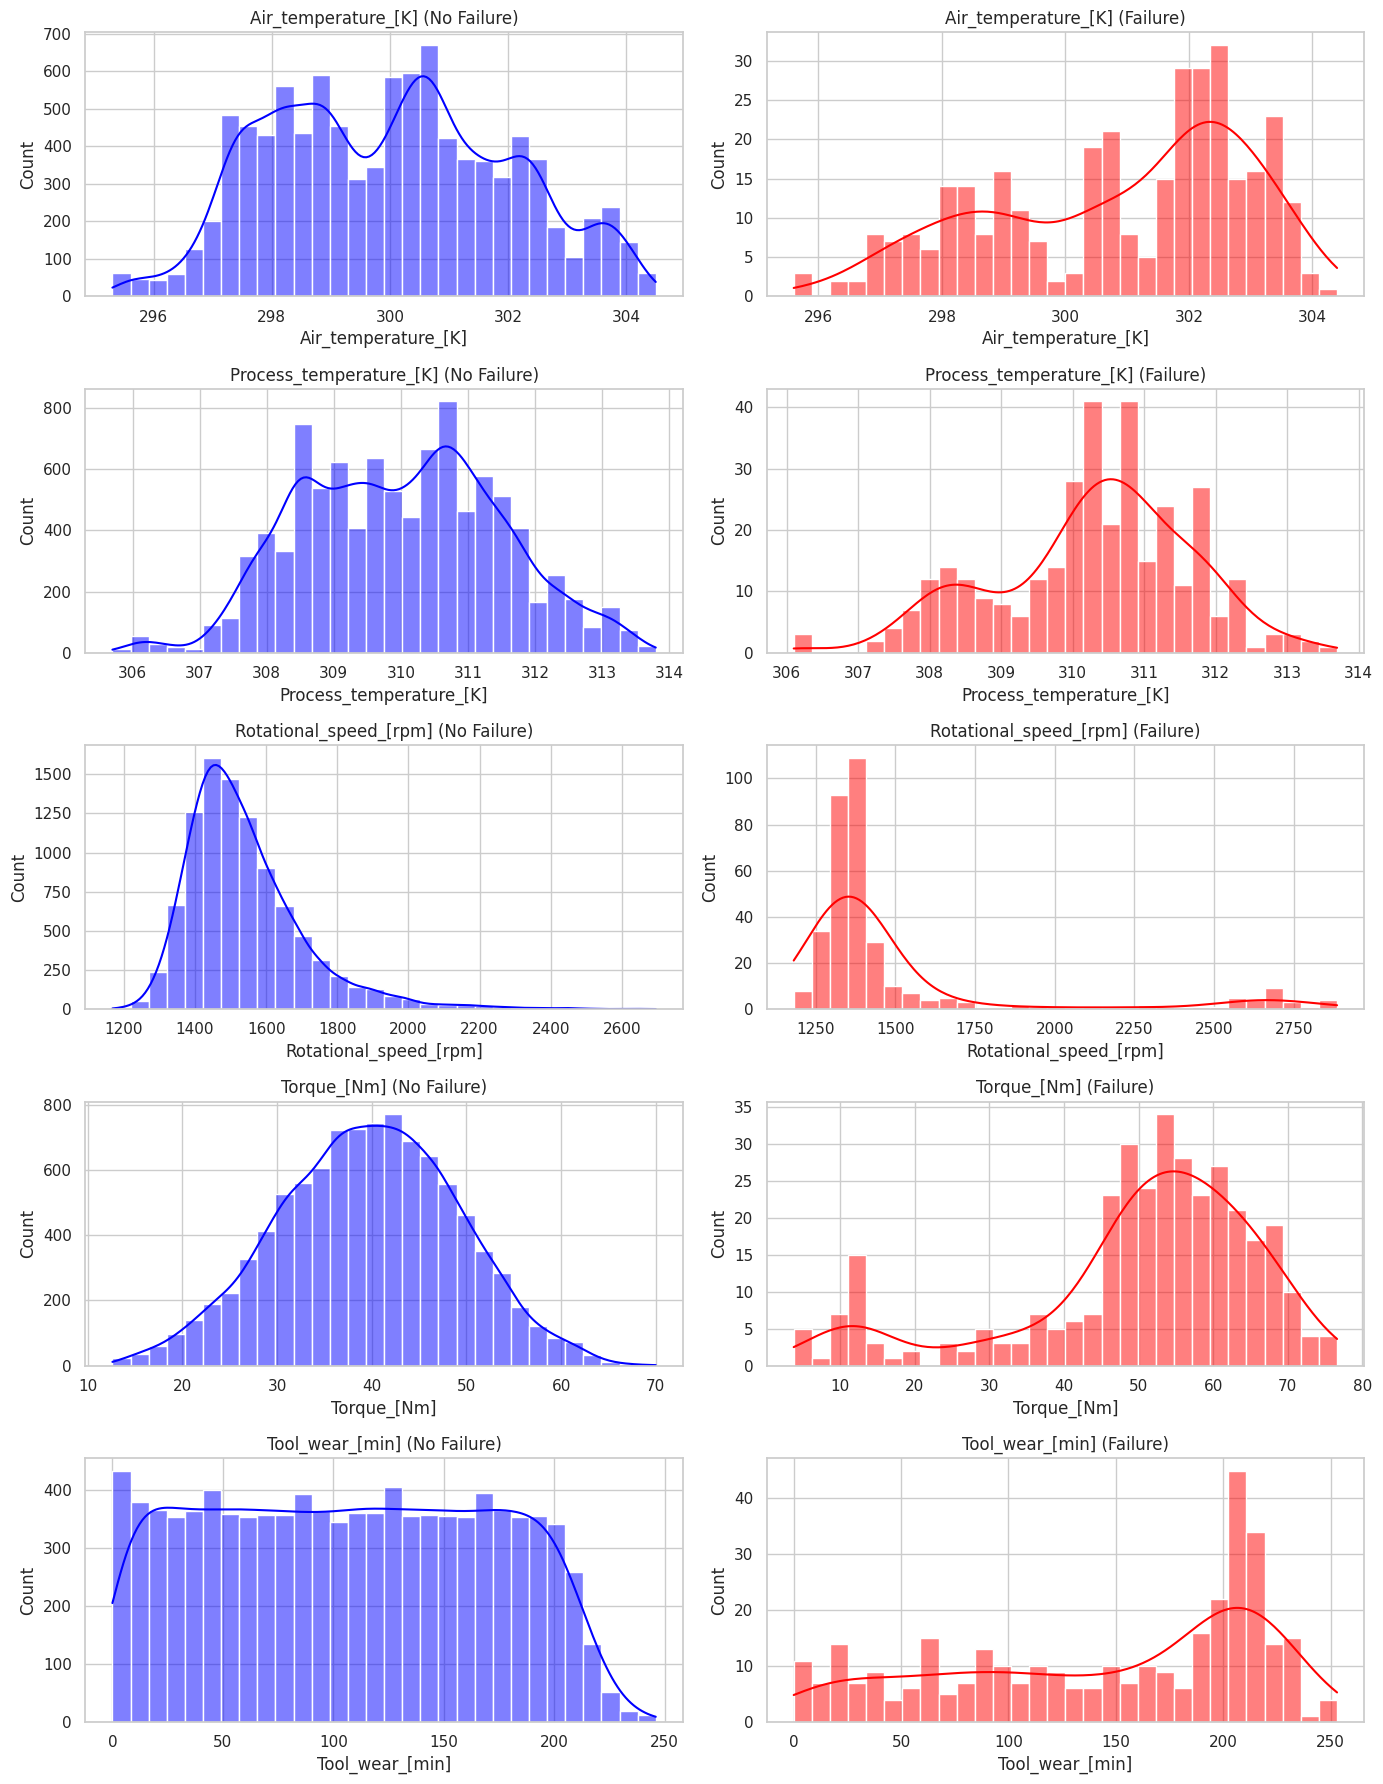

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Features to compare
features = [
    'Air_temperature_[K]',
    'Process_temperature_[K]',
    'Rotational_speed_[rpm]',
    'Torque_[Nm]',
    'Tool_wear_[min]'
]

# Create subplots
fig, axes = plt.subplots(len(features), 2, figsize=(14, 18))

for i, feature in enumerate(features):

    # No Failure (Target = 0)
    sns.histplot(
        df[df['Target'] == 0][feature],
        bins=30,
        kde=True,
        color='blue',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{feature} (No Failure)')

    # Failure (Target = 1)
    sns.histplot(
        df[df['Target'] == 1][feature],
        bins=30,
        kde=True,
        color='red',
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{feature} (Failure)')

plt.tight_layout()
plt.show()

### Key Observations

Some features show clear differences between failure and non-failure cases. In particular, torque and tool wear tend to be higher when failures occur.

Other features, such as rotational speed, show more overlap between the two groups, suggesting they may be less useful for prediction on their own.

### Summary Statistics by Failure Status

Here, we calculate summary statistics for each feature, grouped by Target (0 = No Failure, 1 = Failure).

These statistics help us compare typical values and variation between the two groups, making patterns in the data easier to interpret.

In [ ]:
summary_stats = (
    df.groupby('Target')[features]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(2)
)

# Keep only the columns you want
summary_stats = summary_stats.loc[:, (slice(None), ['min', '25%', '50%', '75%', 'max', 'mean', 'std'])]

# Reshape
summary_stats = summary_stats.stack(level=0).reset_index()
summary_stats.columns = ['Target', 'Feature', 'Min', 'Q1', 'Median', 'Q3', 'Max', 'Mean', 'Std']

# Sort for readability
summary_stats = summary_stats.sort_values(['Feature', 'Target']).reset_index(drop=True)

summary_stats

/tmp/ipykernel_13702/41633648.py:11: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  summary_stats = summary_stats.stack(level=0).reset_index()


,Target,Feature,Min,Q1,Median,Q3,Max,Mean,Std
0,0,Air_temperature_[K],295.3,298.30,300.0,301.5,304.5,299.97,1.99
1,1,Air_temperature_[K],295.6,299.10,301.6,302.5,304.4,300.89,2.07
2,0,Process_temperature_[K],305.7,308.80,310.0,311.1,313.8,310.00,1.49
3,1,Process_temperature_[K],306.1,309.50,310.4,311.2,313.7,310.29,1.36
4,0,Rotational_speed_[rpm],1168.0,1429.00,1507.0,1615.0,2695.0,1540.26,167.39
5,1,Rotational_speed_[rpm],1181.0,1326.50,1365.0,1421.5,2886.0,1496.49,384.94
6,0,Tool_wear_[min],0.0,52.00,107.0,160.0,246.0,106.69,62.95
7,1,Tool_wear_[min],0.0,84.50,165.0,207.5,253.0,143.78,72.76
8,0,Torque_[Nm],12.6,33.10,39.9,46.3,70.0,39.63,9.47
9,1,Torque_[Nm],3.8,45.95,53.7,61.2,76.6,50.17,16.37


### Interpreting the Summary Statistics

The summary statistics confirm patterns we saw in the visualizations. Torque and tool wear have higher average values in failure cases, suggesting they may be strong indicators of failure.

Rotational speed also shows greater variability in failure cases, while temperature features remain relatively similar between groups, indicating weaker predictive signals.

### Train an SVM Model

In this step, we train a Support Vector Machine (SVM) model to predict whether a machine will fail.

We scale the input features, train the model on multiple stratified splits, and generate predictions to evaluate how well the model identifies failures.

In [8]:
# Train an SVM model to predict machine failure
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X = df[features]
y = df['Target']

# Create stratified train/test splits
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

# Build a pipeline: scale the data, then train the SVM
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        class_weight='balanced',
        probability=True
    ))
])

all_y_true = []
all_y_pred = []

# Train and test across multiple splits
for train_index, test_index in cv.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

### Train a KNN Model

Next, we train a K-Nearest Neighbors (KNN) model using the same features and target.

This gives us a second machine learning approach that we can compare with SVM to see which model performs better on this dataset.

In [5]:
# Train a KNN model to predict machine failure
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = df[features]
y = df['Target']

# Create stratified train/test splits
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.20,
    random_state=42
)

# Build a pipeline: scale the data, then train the KNN model
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=5
    ))
])

all_y_true_knn = []
all_y_pred_knn = []

# Train and test across multiple splits
for train_index, test_index in cv.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    knn_model.fit(X_train, y_train)
    y_pred_knn = knn_model.predict(X_test)

    all_y_true_knn.extend(y_test)
    all_y_pred_knn.extend(y_pred_knn)

### Confusion Matrix Comparison

We use confusion matrices to evaluate how well each model predicts failures and non-failures.

This helps us see not only overall performance, but also how often the model correctly identifies failure cases versus making errors.

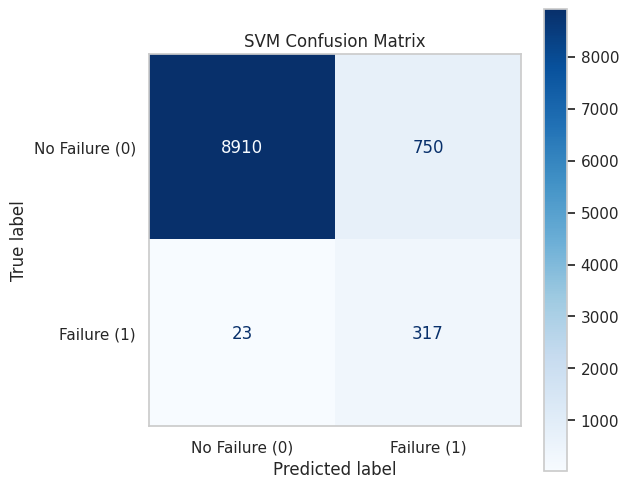

Total predictions: 10000


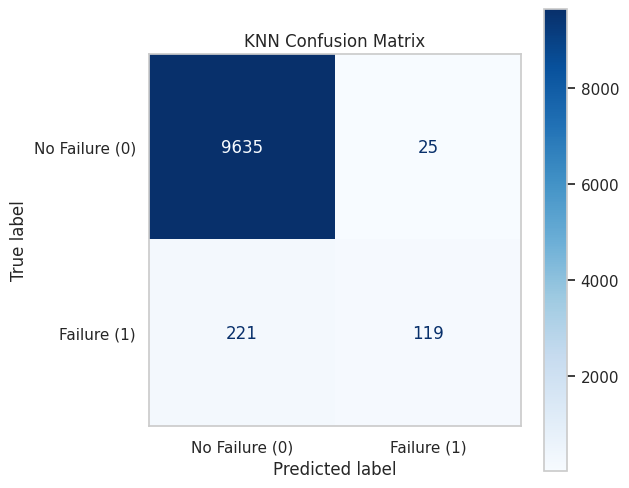

Total predictions: 10000


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Failure (0)', 'Failure (1)']
    )

    disp.plot(cmap='Blues', ax=ax, colorbar=True)

    plt.title(title)
    plt.grid(False)
    plt.show()

    print("Total predictions:", np.sum(cm))


# SVM Confusion Matrix
plot_confusion_matrix(all_y_true, all_y_pred, "SVM Confusion Matrix")

# KNN Confusion Matrix
plot_confusion_matrix(all_y_true_knn, all_y_pred_knn, "KNN Confusion Matrix")

### 🔍 Interpreting the Confusion Matrices

The confusion matrices here may differ from those in Orange Data Mining because the models, settings, and data splitting methods are not identical. Even small differences in how the data is split or how the models are configured can lead to different results.

In this dataset, 1 represents a machine failure and 0 represents normal operation. The confusion matrix shows how often the model correctly or incorrectly predicts these outcomes.

- True Positives: correctly predicted failures  
- True Negatives: correctly predicted non-failures  
- False Positives: predicted failure when none occurred  
- False Negatives: missed failures  

In predictive maintenance, false negatives are especially important because they represent failures the model did not catch. SVM seems to be a better model choice as there are only 23 false negatives compared to the 221 false negatives for KNN.

### Model Performance Metrics

We calculate accuracy, precision, recall, and F1 score to evaluate how well each model predicts machine failure.

These metrics help us understand not only overall performance, but also how effectively the model identifies actual failures.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---- SVM Metrics ----
print("SVM Performance Metrics")
print("------------------------")
print("Accuracy:", round(accuracy_score(all_y_true, all_y_pred), 3))
print("Precision:", round(precision_score(all_y_true, all_y_pred), 3))
print("Recall:", round(recall_score(all_y_true, all_y_pred), 3))
print("F1 Score:", round(f1_score(all_y_true, all_y_pred), 3))

print("\n")

# ---- KNN Metrics ----
print("KNN Performance Metrics")
print("------------------------")
print("Accuracy:", round(accuracy_score(all_y_true_knn, all_y_pred_knn), 3))
print("Precision:", round(precision_score(all_y_true_knn, all_y_pred_knn), 3))
print("Recall:", round(recall_score(all_y_true_knn, all_y_pred_knn), 3))
print("F1 Score:", round(f1_score(all_y_true_knn, all_y_pred_knn), 3))

SVM Performance Metrics
------------------------
Accuracy: 0.923
Precision: 0.297
Recall: 0.932
F1 Score: 0.451


KNN Performance Metrics
------------------------
Accuracy: 0.975
Precision: 0.826
Recall: 0.35
F1 Score: 0.492


### Understanding the Metrics

Precision measures how well the model avoids false positives—predicting a failure when the machine would not actually fail.

Recall measures how well the model avoids false negatives—missing a failure that actually occurs.

In this context:
- A false positive means predicting a failure when the machine is actually fine  
- A false negative means missing a real failure  

In predictive maintenance, recall is more important because missing a failure can lead to unexpected downtime and higher costs.

The F1 score is a balance between precision and recall, and is useful when both are equally important.

In this case, the SVM model performs better at identifying failures (higher recall), making it a better choice for this problem.

### 📈 ROC Curve Comparison

The ROC curve shows how well each model separates failure and non-failure cases across different thresholds.

A curve closer to the top-left corner and a higher AUC indicate better performance. This helps us compare how effectively each model identifies machine failures.

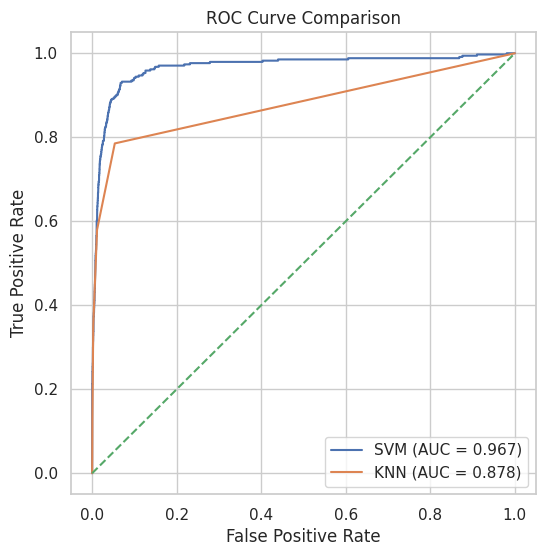

In [9]:
# ROC Curve for SVM and KNN

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Store true labels and probabilities
all_y_true = []
all_y_probs_svm = []
all_y_probs_knn = []

# Loop through the same splits
for train_index, test_index in cv.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # SVM probabilities
    svm_model.fit(X_train, y_train)
    y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

    # KNN probabilities
    knn_model.fit(X_train, y_train)
    y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test)
    all_y_probs_svm.extend(y_prob_svm)
    all_y_probs_knn.extend(y_prob_knn)

# Convert to arrays
all_y_true = np.array(all_y_true)
all_y_probs_svm = np.array(all_y_probs_svm)
all_y_probs_knn = np.array(all_y_probs_knn)

# Compute ROC for SVM
fpr_svm, tpr_svm, _ = roc_curve(all_y_true, all_y_probs_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# Compute ROC for KNN
fpr_knn, tpr_knn, _ = roc_curve(all_y_true, all_y_probs_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# Plot ROC curves
plt.figure(figsize=(6,6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})")

# Baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Final Summary and Key Takeaways

The ROC curve shows that the SVM model outperforms KNN, with a higher AUC, indicating better overall ability to distinguish between failure and non-failure cases. This supports our earlier findings from the confusion matrix and recall, where SVM was more effective at identifying machine failures.

In this lesson, we walked through a complete predictive maintenance workflow. We explored the data, identified patterns in key features, and used those insights to train machine learning models. We then evaluated model performance using multiple metrics and visual tools to understand how well each model detects failures.

Overall, we saw how machine learning can be applied to real-world manufacturing data to help predict equipment failures, reduce downtime, and support more proactive decision-making.

---

### Next Steps

All materials for this lesson, including the dataset and notebook, are available in the GitHub repository (tinyurl.com/grccdemo).

To continue exploring, you can:
- Modify the model parameters (e.g., adjust KNN neighbors or SVM settings)  
- Try additional models and compare their performance  
- Explore which features have the strongest impact on predictions  
- Apply this workflow to a different dataset  

These steps will help you build confidence in applying machine learning to real-world problems beyond this example.